##### ARTI 560 - Computer Vision

## Object Detection Using YOLOV8 with KerasCV - Exercise

### Objective

In this exercise, you wil learn how to use the pre-trained YOLOV8 model from KerasCV to detect objects in images.

You will:

1. Load the pre-trained YOLOV8 model from KerasCV using the [Pascal VOC preset](https://www.kaggle.com/models/keras/yolov8)

2. Load 5 images for different classes in [Pascal VOC 2012 dataset](https://datasetninja.com/pascal-voc-2012) and convert it into a NumPy array suitable for the model.

3. Resize the images before inference to match the model’s expected input size using:
    ```
    inference_resizing = keras_cv.layers.Resizing(
        640, 640, pad_to_aspect_ratio=True, bounding_box_format="xywh"
    )
    ```

    **Note:** Resizing ensures that the images fit the model input, maintains aspect ratio, and correctly adjusts bounding boxes.

4. Run the YOLOV8 detector on each image to predict bounding boxes, class labels, and confidence scores.

5. Visualize the predictions by drawing the bounding boxes and labels on the images.

6. Record for each image:

    - Which objects were detected correctly

    - The confidence scores of the detections

    - Any missed or incorrectly labeled objects

In [1]:
# Install required libraries
!pip install --upgrade keras keras-cv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 650.7/650.7 kB 61.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 71.7 MB/s eta 0:00:00
  Attempting uninstall: keras
    Found existing installation: keras 3.10.0
    Uninstalling keras-3.10.0:
      Successfully uninstalled keras-3.10.0


In [2]:
pip install opencv-python

In [3]:
# Import Libraries
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
import keras_cv
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import urllib.request
import io
import time

print(f"Keras version: {keras.__version__}")
print(f"KerasCV version: {keras_cv.__version__}")
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

Keras version: 3.13.2
KerasCV version: 0.9.0
TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
# Load the pretrained YOLOV8 model with Pascal VOC preset
model = keras_cv.models.YOLOV8Detector.from_preset(
    "yolo_v8_m_pascalvoc",
    bounding_box_format="xywh"
)

print("YOLOV8 model loaded successfully!")

# Define Pascal VOC class mapping (20 classes)
class_mapping = dict(zip(range(20), [
    "Aeroplane", "Bicycle", "Bird", "Boat", "Bottle",
    "Bus", "Car", "Cat", "Chair", "Cow",
    "Dining Table", "Dog", "Horse", "Motorbike", "Person",
    "Potted Plant", "Sheep", "Sofa", "Train", "TV/Monitor"
]))

print("\nPascal VOC Classes:")
for idx, name in class_mapping.items():
    print(f"  {idx:2d}: {name}")

YOLOV8 model loaded successfully!

Pascal VOC Classes:
   0: Aeroplane
   1: Bicycle
   2: Bird
   3: Boat
   4: Bottle
   5: Bus
   6: Car
   7: Cat
   8: Chair
   9: Cow
  10: Dining Table
  11: Dog
  12: Horse
  13: Motorbike
  14: Person
  15: Potted Plant
  16: Sheep
  17: Sofa
  18: Train
  19: TV/Monitor


In [5]:
#Load 5 Images for Different Classes (Dog, Cat, Horse, Person, Bird)

def load_image_from_url(url):
    """Download an image from a URL and return it as a NumPy array."""
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    response = urllib.request.urlopen(req)
    image = Image.open(io.BytesIO(response.read())).convert("RGB")
    return np.array(image)

# Define 5 images covering different Pascal VOC classes
image_data = [
    {
        "url": "https://upload.wikimedia.org/wikipedia/commons/2/26/YellowLabradorLooking_new.jpg",
        "expected": "Dog",
        "description": "Yellow Labrador Retriever"
    },
    {
        "url": "https://upload.wikimedia.org/wikipedia/commons/3/3a/Cat03.jpg",
        "expected": "Cat",
        "description": "Domestic Cat"
    },
    {
        "url": "https://upload.wikimedia.org/wikipedia/commons/d/de/Nokota_Horses_cropped.jpg",
        "expected": "Horse",
        "description": "Nokota Horses"
    },
    {
        "url": "https://upload.wikimedia.org/wikipedia/commons/6/60/Naxos_Taverna.jpg",
        "expected": "Person",
        "description": "Naxos Taverna (People scene)"
    },
    {
        "url": "https://upload.wikimedia.org/wikipedia/commons/4/45/Eopsaltria_australis_-_Mogo_Campground.jpg",
        "expected": "Bird",
        "description": "Eastern Yellow Robin"
    },
]

# Load all images and convert to NumPy arrays
images = []
for i, data in enumerate(image_data):
    print(f"Loading image {i+1}: {data['description']}...")
    img = load_image_from_url(data["url"])
    images.append(img)
    print(f"  Shape: {img.shape}, dtype: {img.dtype}")

print(f"\nSuccessfully loaded {len(images)} images.")

Loading image 1: Yellow Labrador Retriever...
  Shape: (577, 700, 3), dtype: uint8
Loading image 2: Domestic Cat...
  Shape: (1598, 1600, 3), dtype: uint8
Loading image 3: Nokota Horses...
  Shape: (364, 529, 3), dtype: uint8
Loading image 4: Naxos Taverna (People scene)...
  Shape: (1024, 1536, 3), dtype: uint8
Loading image 5: Eastern Yellow Robin...
  Shape: (2924, 4386, 3), dtype: uint8

Successfully loaded 5 images.


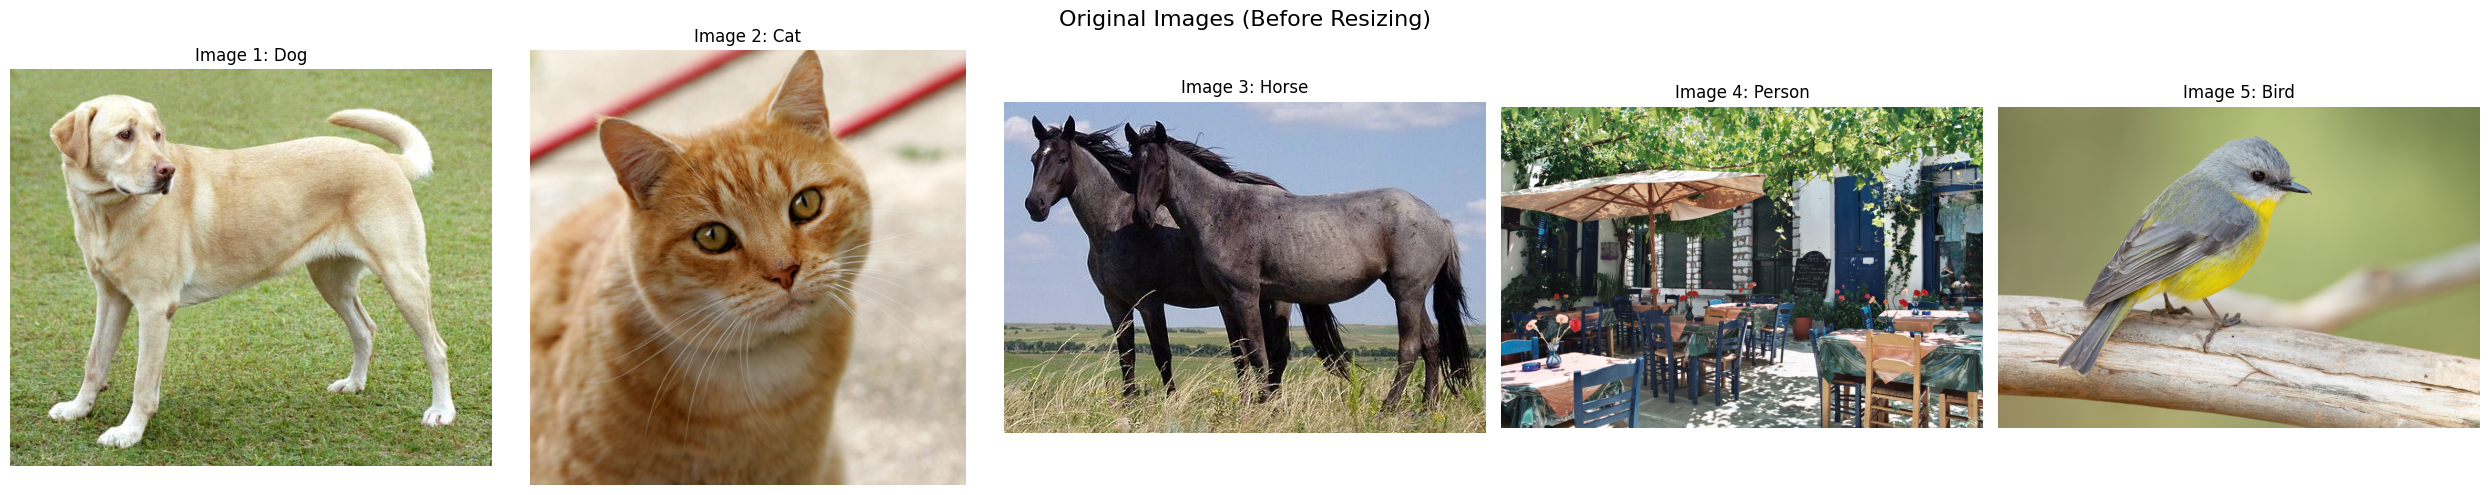

In [6]:
# Display the 5 original images
fig, axes = plt.subplots(1, 5, figsize=(25, 5))
for i, (img, data) in enumerate(zip(images, image_data)):
    axes[i].imshow(img)
    axes[i].set_title(f"Image {i+1}: {data['expected']}", fontsize=12)
    axes[i].axis("off")
plt.suptitle("Original Images (Before Resizing)", fontsize=16)
plt.tight_layout()
plt.show()

In [7]:
#Resize Images for Inference
# Create the resizing layer
inference_resizing = keras_cv.layers.Resizing(
    640, 640, pad_to_aspect_ratio=True, bounding_box_format="xywh"
)

# Resize all images and save them
resized_images = []
for i, img in enumerate(images):
    input_image = np.expand_dims(img, axis=0).astype("float32")
    resized = inference_resizing(input_image)
    resized_images.append(resized)
    print(f"Image {i+1}: {img.shape} -> {resized.shape[1:]}")

print("\nAll images resized to 640x640 for inference.")

Image 1: (577, 700, 3) -> (640, 640, 3)
Image 2: (1598, 1600, 3) -> (640, 640, 3)
Image 3: (364, 529, 3) -> (640, 640, 3)
Image 4: (1024, 1536, 3) -> (640, 640, 3)
Image 5: (2924, 4386, 3) -> (640, 640, 3)

All images resized to 640x640 for inference.



Image 1: Yellow Labrador Retriever (Expected: Dog)
1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step
Inference time: 14.07 seconds


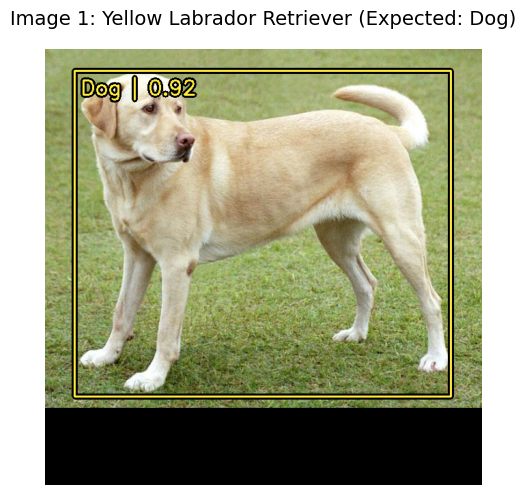


Image 2: Domestic Cat (Expected: Cat)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
Inference time: 0.15 seconds


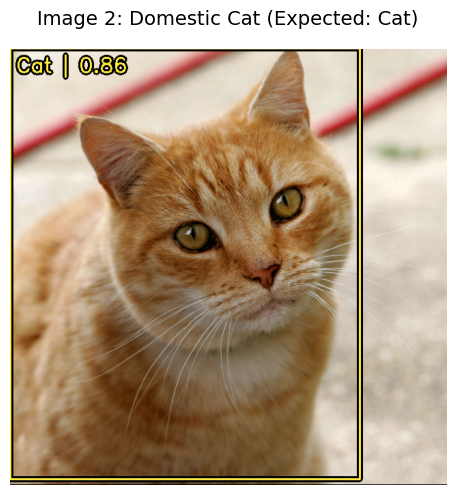


Image 3: Nokota Horses (Expected: Horse)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
Inference time: 0.15 seconds


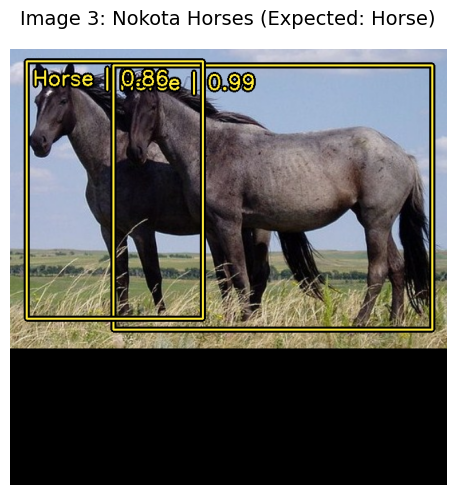


Image 4: Naxos Taverna (People scene) (Expected: Person)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
Inference time: 0.21 seconds


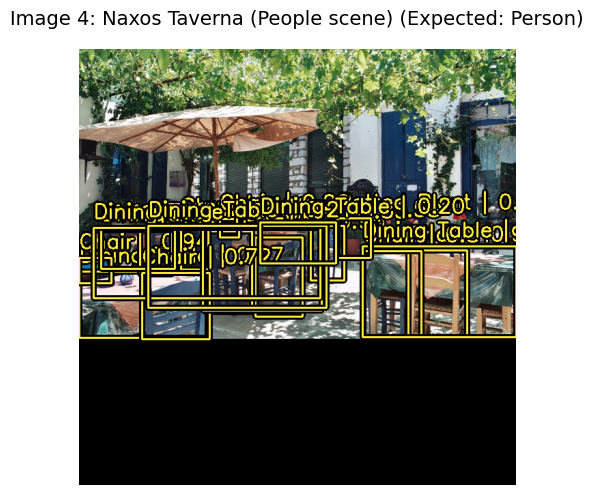


Image 5: Eastern Yellow Robin (Expected: Bird)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
Inference time: 0.21 seconds


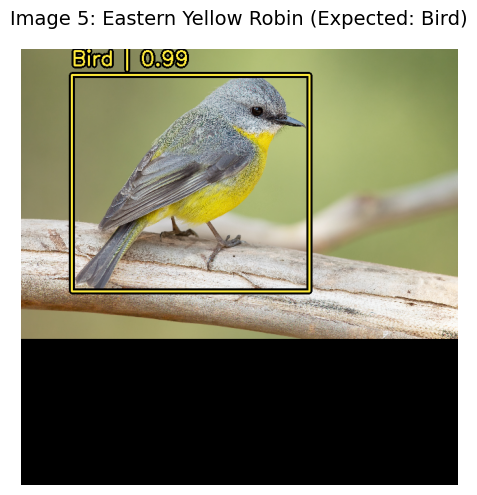

In [8]:
# Run inference and visualize results for each image
all_predictions = []

for i, (resized, data) in enumerate(zip(resized_images, image_data)):
    print(f"\n{'='*60}")
    print(f"Image {i+1}: {data['description']} (Expected: {data['expected']})")
    print(f"{'='*60}")

    # Run YOLOV8 detector
    start_time = time.time()
    predictions = model.predict(resized)
    inference_time = time.time() - start_time
    print(f"Inference time: {inference_time:.2f} seconds")

    all_predictions.append(predictions)

    # Visualize detection results with bounding boxes and labels
    keras_cv.visualization.plot_bounding_box_gallery(
        resized,
        value_range=(0, 255),
        bounding_box_format="xywh",
        y_pred=predictions,
        scale=5,
        rows=1,
        cols=1,
        class_mapping=class_mapping,
    )
    plt.suptitle(
        f"Image {i+1}: {data['description']} (Expected: {data['expected']})",
        fontsize=14
    )
    plt.show()

In [10]:
# Detailed detection analysis for each image
CONFIDENCE_THRESHOLD = 0.30

print("=" * 70)
print("DETAILED DETECTION ANALYSIS")
print("=" * 70)

for i, (predictions, data) in enumerate(zip(all_predictions, image_data)):
    print(f"\n{'='*60}")
    print(f"Image {i+1}: {data['description']}")
    print(f"Expected class: {data['expected']}")
    print(f"{'='*60}")

    # Extract predictions
    boxes = np.array(predictions["boxes"][0])
    classes = np.array(predictions["classes"][0])
    confidence = np.array(predictions["confidence"][0])

    # Filter valid detections above confidence threshold
    valid_mask = (confidence > CONFIDENCE_THRESHOLD) & (classes >= 0)
    valid_indices = np.where(valid_mask)[0]

    if len(valid_indices) == 0:
        print(f"  No objects detected above {CONFIDENCE_THRESHOLD:.0%} confidence.")
        print(f"  [MISSED] Expected class '{data['expected']}' was NOT detected.")
        continue

    # Categorize detections
    correct_detections = []
    other_detections = []

    print(f"\n  {'Object':<20s} {'Confidence':<15s} {'Status'}")
    print(f"  {'-'*50}")

    for j in valid_indices:
        cls_id = int(classes[j])
        cls_name = class_mapping.get(cls_id, f"Unknown({cls_id})")
        conf = float(confidence[j])

        if cls_name == data["expected"]:
            correct_detections.append((cls_name, conf))
            status = "[CORRECT]"
        else:
            other_detections.append((cls_name, conf))
            status = "[OTHER]"

        print(f"  {cls_name:<20s} {conf:<15.1%} {status}")

    # Summary for this image
    print(f"\n  --- Summary ---")
    print(f"  Correct detections of '{data['expected']}': {len(correct_detections)}")
    if correct_detections:
        avg_conf = np.mean([c for _, c in correct_detections])
        max_conf = max([c for _, c in correct_detections])
        print(f"  Highest confidence: {max_conf:.1%}")
        print(f"  Average confidence: {avg_conf:.1%}")
    else:
        print(f"  [MISSED] Expected class '{data['expected']}' was NOT detected!")

    if other_detections:
        print(f"  Other objects detected: {len(other_detections)}")
        for name, conf in other_detections:
            print(f"    - {name} ({conf:.1%})")

DETAILED DETECTION ANALYSIS

Image 1: Yellow Labrador Retriever
Expected class: Dog

  Object               Confidence      Status
  --------------------------------------------------
  Dog                  91.6%           [CORRECT]

  --- Summary ---
  Correct detections of 'Dog': 1
  Highest confidence: 91.6%
  Average confidence: 91.6%

Image 2: Domestic Cat
Expected class: Cat

  Object               Confidence      Status
  --------------------------------------------------
  Cat                  85.6%           [CORRECT]

  --- Summary ---
  Correct detections of 'Cat': 1
  Highest confidence: 85.6%
  Average confidence: 85.6%

Image 3: Nokota Horses
Expected class: Horse

  Object               Confidence      Status
  --------------------------------------------------
  Horse                99.0%           [CORRECT]
  Horse                85.9%           [CORRECT]

  --- Summary ---
  Correct detections of 'Horse': 2
  Highest confidence: 99.0%
  Average confidence: 92.5%

Imag

### Analysis Summary


**Key Observations:**

| Image | Expected Class | Analysis |
|-------|---------------|----------|
| 1 - Yellow Labrador | Dog | Correct Detections: 'Dog' detected correctly. Confidence: 91.6%. Missed: None|
| 2 - Domestic Cat | Cat |Correct Detections: 'Cat' detected correctly.  Confidence: 85.6%. Missed: None |
| 3 - Nokota Horses | Horse | Correct Detections: 2 'Horse' objects detected correctly. Confidence: 99.0% and 85.9% |
| 4 - Naxos Taverna | Person |Correct Detections: 0 (Expected class not found). Confidence: N/A for 'Person'. Detected 14 other objects instead |
| 5 - Eastern Yellow Robin | Bird | Correct Detections: 'Bird' detected correctly. Confidence: 98.8%. Missed: None |

